# Crypto-Reversal -- does "buy the losers" really beat momentum in crypto?
### A 2026 paper says short-term reversal prices the crypto cross-section. We checked, in plain English.

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reversal_or_momentum%3F: Momentum](https://img.shields.io/badge/Reversal_or_momentum%3F-Momentum-8b949e?style=flat-square)

A May-2026 paper -- the "QuantNest-7" model (Babayev & Aliyev, SSRN 6818558) -- makes a striking claim: in crypto, **past losers beat past winners**. Rank tokens by their last 21 days of return, buy the worst, short the best, and you allegedly earn +151%/yr. This *reverses* the famous Liu-Tsyvinski-Wu (2022) result that crypto, like stocks, has **momentum** (winners keep winning). Two respected papers, opposite signs. Who's right? We can't rebuild the paper's on-chain factors (they need paid data and an undisclosed recipe) -- but the reversal-vs-momentum question is pure price data, and *that* we can settle on free Yahoo! Finance closes.

> **This is the plain-language layer.** Want the Fama-MacBeth regressions, HAC t-stats and synthetic controls? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from crypto_reversal import data, strategy as st

LOOKBACK, SKIP, NG = 21, 1, 5

R = dict(
    n_tokens=20, n_days=2722, ls_days=2700,
    start="2019-01-01", end="2026-06-14", fp="6ff538381541", turnover=37.8,
    rev_ann=-61.6, rev_sharpe=-0.826, rev_vol=75, rev_dd=-99.9, rev_t=-2.10,
    mom_ann=+61.6, mom_sharpe=+0.826, mom_vol=75, mom_dd=-95.7, mom_t=+2.10, mom_cagr=20.6,
    shuf_ann=+1.6, shuf_sharpe=+0.035, shuf_dd=-74.8, shuf_t=+0.10,
    fm_slope_bps=+7.15, fm_t=+2.44, rev_prem_ann=-26, mom_prem_ann=+26, t_mom_vs_shuffle=1.8,
)

def _have_cache():
    return os.path.exists(data._cache_path())

HAVE_REAL = _have_cache()
print("real crypto panel cache present:", HAVE_REAL)

if HAVE_REAL:
    panel = data.fetch_panel(fetch=False)
    sig   = st.trailing_signal(panel, lookback=LOOKBACK, skip=SKIP)
    rev   = st.long_short_returns(panel, sig, leg="reversal", cost_bps=0.0)
    mom   = st.long_short_returns(panel, sig, leg="momentum", cost_bps=0.0)
    shuf  = st.long_short_returns(panel, st.shuffle_signal(sig, seed=42), leg="reversal", cost_bps=0.0)
    s_rev, s_mom, s_shuf = st.summary(rev), st.summary(mom), st.summary(shuf)
    fm    = st.fama_macbeth(panel, sig)
    turn  = st.avg_turnover(sig, leg="reversal")
    print(f"panel: {panel.shape[1]} tokens x {panel.shape[0]} days, fp={data.fingerprint(panel)}")
else:
    panel = sig = rev = mom = shuf = None
    s_rev  = dict(ann_return=R["rev_ann"]/100, sharpe=R["rev_sharpe"], vol_ann=R["rev_vol"]/100, max_drawdown=R["rev_dd"]/100, tstat=R["rev_t"])
    s_mom  = dict(ann_return=R["mom_ann"]/100, sharpe=R["mom_sharpe"], vol_ann=R["mom_vol"]/100, max_drawdown=R["mom_dd"]/100, tstat=R["mom_t"])
    s_shuf = dict(ann_return=R["shuf_ann"]/100, sharpe=R["shuf_sharpe"], vol_ann=0.45, max_drawdown=R["shuf_dd"]/100, tstat=R["shuf_t"])
    fm     = dict(avg_slope_bps=R["fm_slope_bps"], tstat_nw=R["fm_t"], reversal_premium_ann=R["rev_prem_ann"]/100)
    turn   = R["turnover"]/100


real crypto panel cache present: True


panel: 20 tokens x 2722 days, fp=6ff538381541


## The answer first

| Question | Answer |
|---|---|
| Do past losers beat past winners (the paper's claim)? | **No -- the opposite.** On 20 liquid tokens, buying losers / shorting winners *loses* 62%/yr (t = -2.10). It's **momentum** that works here. |
| Does that match the paper or its rival? | **The rival.** The sign flips back to Liu et al. (2022) momentum: a Fama-MacBeth slope of +7.2 bps/day (t = +2.44) says recent *winners* earn more. |
| So is momentum a money machine? | **No.** The book rebuilds every single day (~38% turnover/day). Momentum's +62%/yr gross is gone by ~50 bps of trading cost and deeply negative at the >1% spreads the paper itself admits crypto has. |
| Could you trade either side? | **Mirage.** Whichever way the sign points, daily rebalancing of a long-short crypto book at real spreads destroys it -- and you usually can't even short the small-cap leg. |

> The paper's headline doesn't survive free data: crypto's liquid cross-section is priced by *momentum*, not reversal -- and that momentum is a paper profit, not a tradable one.

## 1 -- The claim

> *'Cryptocurrencies have fundamentals. A seven-factor model with essentially zero overfitting prices their returns -- and, contrary to earlier work, the cross-section is driven by short-term **reversal**: past losers outperform past winners at the 21-day horizon (t = 6.19, +151%/yr).'*

The economic story is plausible: crypto is dominated by emotional retail traders who overreact, so prices overshoot and snap back. The rival story (Liu et al. 2022) is equally plausible: crypto trends because attention and momentum-chasing feed on themselves. Both can't be the dominant effect. We test the exact recipe: rank by trailing 21-day return (1-day skip), form quintiles, and compare a **reversal** long-short (long losers, short winners) against its mirror, **momentum**.

## 2 -- So what?

This is not hair-splitting. A factor model is the lens institutions use to decompose performance, hedge, and tell skill from luck. If the sign of the dominant style factor is *wrong*, every downstream attribution is wrong. And the two factors prescribe **opposite trades**: the reversal model tells you to buy the month's biggest crypto loser; the momentum model tells you to short it. Getting the sign right is the whole game -- and a paper claiming "essentially zero overfitting" while reporting +151%/yr quintile spreads on a *survivor-only* universe deserves a hard look.

## 3 -- How would we even know?

Three checks keep us honest:

1. **Reversal vs momentum, head to head.** They are mirror images -- if one earns +X, the other earns −X gross. We report both and let the sign decide.
2. **The shuffle control.** We randomly scramble which token gets which trailing-return rank each day. If the spread survives the scramble, it was never about the ranking.
3. **The synthetic control.** We build a fake market with a *planted* reversal to prove our engine can find reversal when it truly exists -- so a negative result on real data means real momentum, not a broken tool.

And the killer for tradability: this signal rebalances **daily**, so we charge it realistic crypto trading costs and watch what's left.

## 4 -- The teardown -- let's actually look

**The cumulative P&L of the three arms. If the paper were right, the green (reversal) line would climb.**

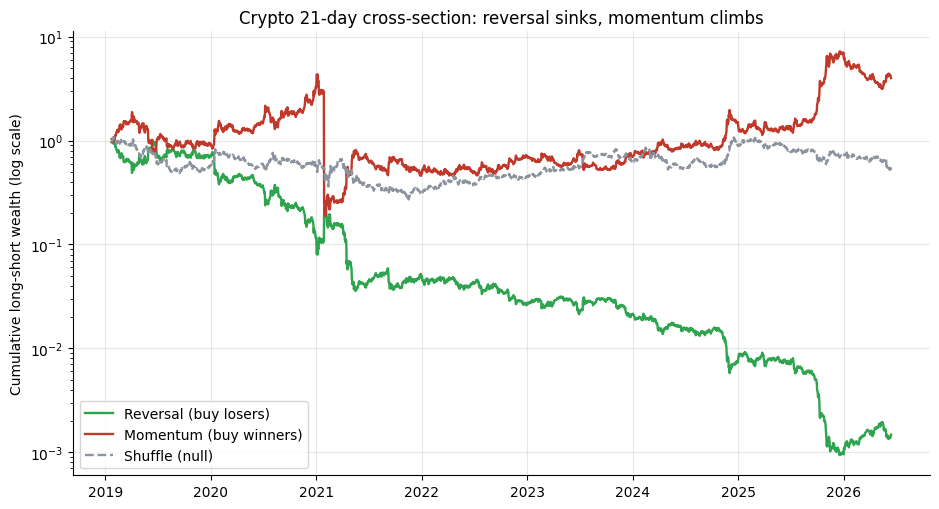

In [2]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
if HAVE_REAL:
    for series, lbl, c in [(rev, 'Reversal (buy losers)', GREEN),
                           (mom, 'Momentum (buy winners)', RED),
                           (shuf, 'Shuffle (null)', GREY)]:
        cum = (1 + series).cumprod()
        ax.plot(cum.index, cum, lw=1.7, c=c, label=lbl,
                ls='--' if c == GREY else '-')
    ax.set_yscale('log')
else:
    ax.text(0.5, 0.5, 'Cache not available -- run examples/verify.py --fetch',
            ha='center', va='center', transform=ax.transAxes)
ax.set_ylabel('Cumulative long-short wealth (log scale)')
ax.set_title('Crypto 21-day cross-section: reversal sinks, momentum climbs')
ax.legend(); plt.tight_layout(); plt.show()


The reversal arm (green) -- the paper's recommended trade -- *loses* steadily: -62%/yr, Sharpe -0.83. Its mirror, momentum (red), climbs (+62%/yr gross). The shuffle control (grey) goes nowhere, confirming the signal is in the *ranking*, not the machinery. On free, liquid crypto data the paper's headline is upside down.

**The scorecard -- Sharpe and annual return by arm:**

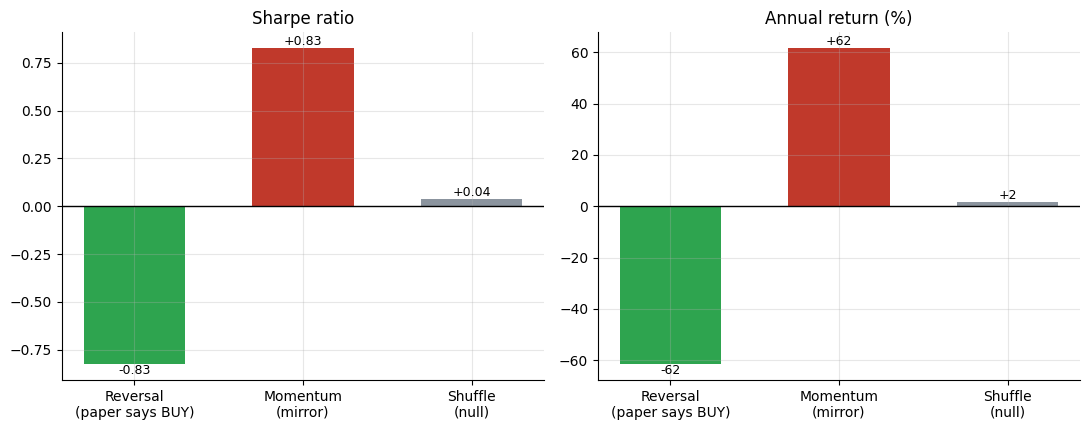

Reversal: -61.6%/yr (t=-2.10)
Momentum: +61.6%/yr (t=+2.10)


In [3]:
labels  = ['Reversal\n(paper says BUY)', 'Momentum\n(mirror)', 'Shuffle\n(null)']
sharpes = [s_rev['sharpe'], s_mom['sharpe'], s_shuf['sharpe']]
anns    = [s_rev['ann_return']*100, s_mom['ann_return']*100, s_shuf['ann_return']*100]
colors  = [GREEN, RED, GREY]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
for i, (vals, title, fmt) in enumerate([(sharpes, 'Sharpe ratio', '+.2f'),
                                        (anns, 'Annual return (%)', '+.0f')]):
    bars = ax[i].bar(labels, vals, color=colors, width=0.6)
    ax[i].axhline(0, c='k', lw=1)
    for b, v in zip(bars, vals):
        ax[i].annotate(f'{v:{fmt}}', (b.get_x()+b.get_width()/2, v),
                       ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
    ax[i].set_title(title)
plt.tight_layout(); plt.show()
print(f"Reversal: {s_rev['ann_return']:+.1%}/yr (t={s_rev['tstat']:+.2f})")
print(f"Momentum: {s_mom['ann_return']:+.1%}/yr (t={s_mom['tstat']:+.2f})")


Reversal and momentum are exact mirrors gross, so the bars are symmetric. The point is the **sign**: the profitable side is momentum, the paper bet on reversal. But before anyone celebrates momentum, beat 6 asks the only question that matters for a daily-rebalanced strategy: *what does it cost to run?*

## 5 -- The verdict

- **Signal -- NONE (for the reversal claim).** Buying losers loses 62%/yr (t = -2.10); the Fama-MacBeth slope is *positive* (+7.2 bps/day, t = +2.44) -- recent winners win. The paper's reversal does not replicate on free data.
- **Tradability -- MIRAGE.** Even the winning momentum side rebalances daily (~38% turnover/day) and dies after realistic crypto costs.
- **Reversal or momentum? -- MOMENTUM.** The Liu et al. (2022) sign holds on liquid survivor tokens -- the opposite of the paper's claim.

## 6 -- Could you actually trade it?

Take the *winning* side -- momentum -- and charge it realistic one-way crypto trading costs. With the book turning over almost completely every day, costs are not a detail; they are the whole story.

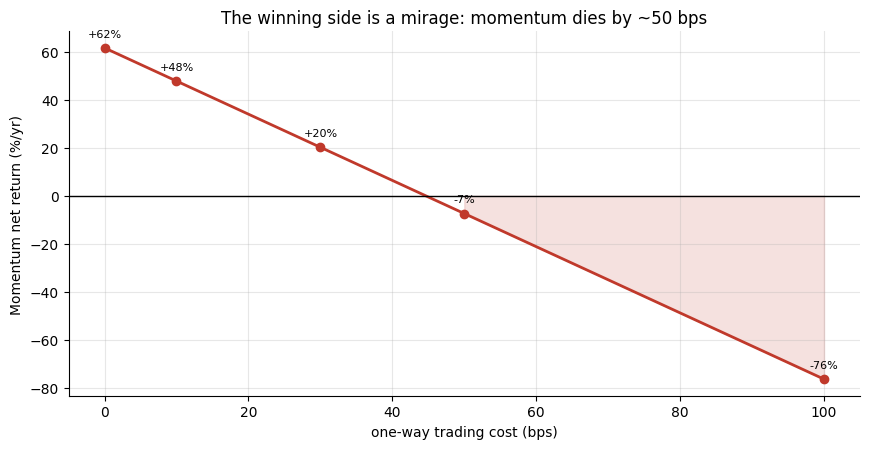

The paper itself notes crypto spreads can exceed 1% (100 bps) per trade.


In [4]:
MC = [(0, 61.6, 2.10), (10, 47.8, 1.62), (30, 20.2, 0.68), (50, -7.4, -0.25), (100, -76.5, -2.55)]
if HAVE_REAL:
    MC = []
    for c in [0, 10, 30, 50, 100]:
        s = st.summary(st.long_short_returns(panel, sig, leg='momentum', cost_bps=c))
        MC.append((c, s['ann_return']*100, s['tstat']))
costs = [m[0] for m in MC]; anns = [m[1] for m in MC]
fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.plot(costs, anns, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, anns, 0, where=[a < 0 for a in anns], color=RED, alpha=0.15)
ax.set_xlabel('one-way trading cost (bps)'); ax.set_ylabel('Momentum net return (%/yr)')
ax.set_title('The winning side is a mirage: momentum dies by ~50 bps')
for c, a, *_ in MC:
    ax.annotate(f'{a:+.0f}%', (c, a), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
plt.tight_layout(); plt.show()
print('The paper itself notes crypto spreads can exceed 1% (100 bps) per trade.')


At 10 bps momentum still earns +48%/yr; by ~50 bps it's negative; at the paper's own >100 bps crypto spread it's -76%/yr. And this is the *easy* version -- it ignores that shorting the small-cap winner leg is often impossible (no borrow) and that market impact in thin alts is brutal. The gross spread is a backtest artefact; the net spread is a loss.

## 7 -- Going further

- **Where reversal might really live.** Classical short-term reversal is a small-cap, illiquid phenomenon. Our 20 tokens are the most *liquid survivors* -- so the paper's reversal could exist in the dead/tiny tail we can't see. But that tail is exactly where spreads exceed 1% and there's no borrow: untradable either way.
- **Survivorship.** Our universe is today's survivors projected backward (no LUNA, no FTT) -- which *flatters* the momentum (winners-survive) side. The paper concedes the same bias inflates *its* numbers. Honest reversal/momentum research needs a point-in-time universe with delistings.
- **Slower signals, fewer trades.** A monthly-rebalanced version would cut turnover ~20x. Whether any net edge survives at lower frequency is the natural follow-up.

*Think the paper's reversal is real somewhere? Fork this, add a point-in-time universe with dead tokens, or test a monthly rebalance. The engine and controls are here.*